# Strategically Robust Trajectory Optimization

Agents planning around each other have to guess what the others will do. A
nominal plan assumes those guesses are right. This notebook works through what
changes when each agent instead plans against the *worst* deviation the others
could make, at every step of the horizon.

The comparison is deliberately three-way, because the obvious objection to
robustness is that it is just timidity with extra steps:

| method | collision cost evaluated at | weight |
|---|---|---|
| **nominal** | the trajectory as planned | $c_1 = 2$ |
| **wider** | the trajectory as planned | $c_1 = 5$ |
| **strategically robust** | the worst case, every step | $c_1 = 2$ |

"Wider" is the naive way to buy separation: leave the model alone and turn the
penalty up. If robustness were only timidity, wider would reproduce it. The
figures below show it does not — the two bend the trajectory in different
places, and buy different amounts of worst-case margin per unit of deviation
from the nominal plan.

**Solver.** Everything below is solved by **single shooting** — over the
controls alone, with states recovered by rolling the dynamics forward. That
removes every equality constraint and roughly halves the variable count. On the
two smaller scenarios it reaches the same optima as the full-space solver to
every digit shown here, about 10x faster; at eight agents it finds a *better*
one. Section 11 compares the two directly.

**Runtime.** Two to three minutes end to end. `BENCH_RUNS` and `BENCH_RUNS_8`
below control how many repetitions the timing section takes.

## 0. Setup

The repository root holds the solver modules; this cell makes them importable
whether Jupyter was started from the root or from `notebooks/`.

In [1]:
import pathlib
import sys

ROOT = pathlib.Path.cwd()
if not (ROOT / 'solvers.py').exists():          # started from notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

FIGDIR = ROOT / 'figures'
FIGDIR.mkdir(exist_ok=True)

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

import plot_style
import plotting
from costs import ALPHA, C1_NOMINAL, C1_WIDER, make_cost
from solvers import (optimize_everystep, optimize_everystep_shooting,
                     optimize_optimal, optimize_optimal_shooting, split_solution)

plot_style.apply()
pd.set_option('display.precision', 4)

# Number of timed repetitions in the runtime section.  The paper uses 30 for the
# small scenarios and 10 for 8 agents; these are lowered so the notebook runs in
# minutes.  Ratios are stable at this count -- the absolute times are not.
BENCH_RUNS = 5
BENCH_RUNS_8 = 3

### The cost

Each agent tracks its own goal and is penalised for being close to anyone else:

$$
J = \sum_i \Big[ (x_{i,H} - x_i^f)^\top Q_f (x_{i,H} - x_i^f)
  + \sum_{t<H} (x_{i,t} - x_i^f)^\top Q (x_{i,t} - x_i^f) + u_{i,t}^\top R\, u_{i,t} \Big]
  \; + \sum_{i<j} \sum_t f\big(\|p_{i,t} - p_{j,t}\|\big)
$$

with the log-barrier pair cost $f(d) = -c_1 \log(d^2 + \alpha)$, which diverges
as $d \to 0$. `make_cost` returns $f$ and $f'$ together — passing a cost without
its derivative silently drops SLSQP into finite differences, which is not just
slower but tends to stop somewhere worse.

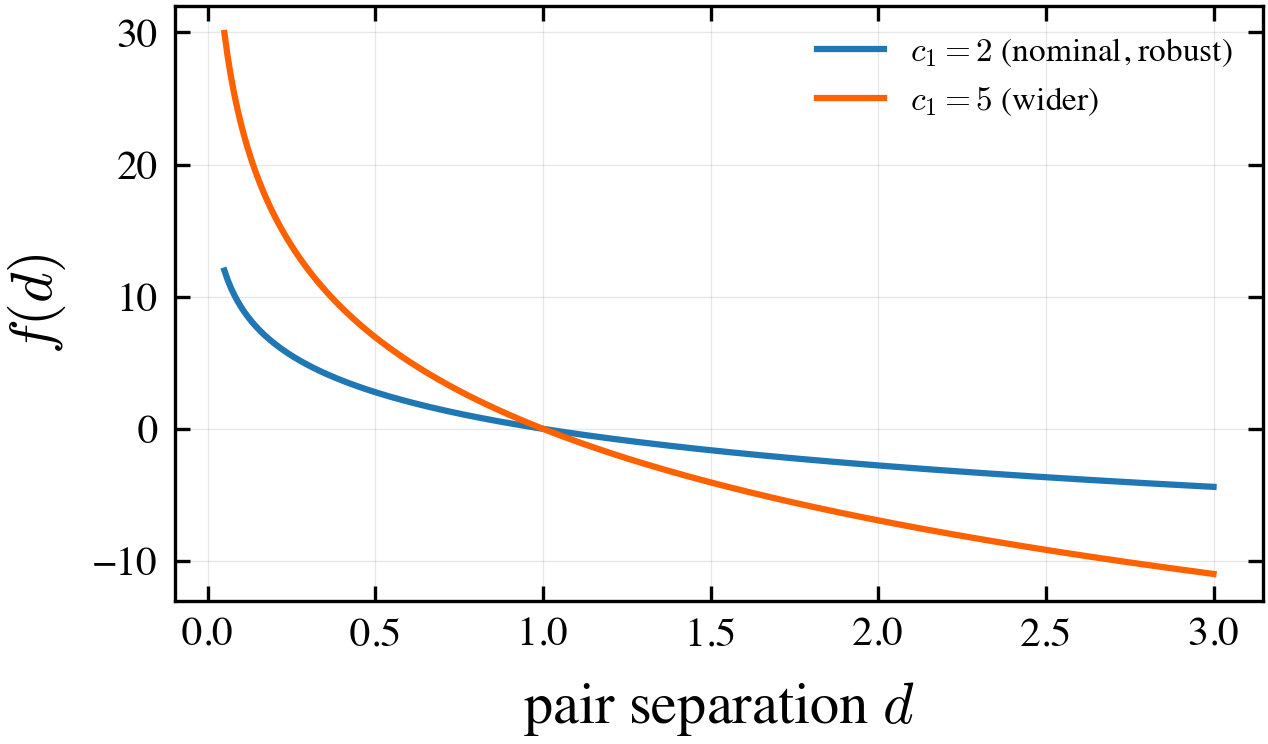

In [2]:
cost_nominal, grad_nominal = make_cost('logarithmic', c1=C1_NOMINAL, alpha=ALPHA)
cost_wider, grad_wider = make_cost('logarithmic', c1=C1_WIDER, alpha=ALPHA)

d = np.linspace(0.05, 3.0, 300)
fig, ax = plt.subplots(figsize=(plotting.PANEL * 1.3, plotting.PANEL * 0.8))
ax.plot(d, cost_nominal(d), color=plot_style.BLUE, label=f'$c_1 = {C1_NOMINAL:g}$ (nominal, robust)')
ax.plot(d, cost_wider(d), color=plot_style.ORANGE, label=f'$c_1 = {C1_WIDER:g}$ (wider)')
ax.set_xlabel('pair separation $d$')
ax.set_ylabel('$f(d)$')
ax.grid(True, linewidth=0.3, alpha=0.3)
ax.tick_params(direction='in', top=True, right=True)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## 1. Head-on: two agents swapping places

Single-integrator dynamics, $A = I$, $B = \Delta t\, I$, horizon $H = 20$ over
2 seconds. The two agents start 2 apart and must exchange positions, so the
straight-line plans intersect. The 0.1 offset in $y$ breaks the symmetry —
without it the problem has two mirror-image optima and the solver picks one
arbitrarily.

In [3]:
H, tf, eps = 20, 2.0, 2.0
dt = tf / H
n_a, sdim, cdim, pdim = 2, 2, 2, 2

A = np.eye(sdim)
B = dt * np.eye(cdim)
Q = np.eye(sdim)
Qf = 150.0 * np.eye(sdim)
R = np.eye(cdim)

x0 = np.array([[0.0, 1.1], [2.0, 1.0]])
xf = np.array([[2.0, 1.0], [0.0, 1.1]])

problem = (x0, xf, A, B, H, Q, R, Qf, n_a, sdim, cdim, pdim)
print(f'{n_a} agents, H = {H}, dt = {dt}, eps = {eps}')
print(f'full space:      {n_a * (H + 1) * sdim + n_a * H * cdim} variables, '
      f'{n_a * sdim + n_a * H * sdim} equality constraints')
print(f'single shooting: {n_a * H * cdim} variables, 0 equality constraints')

2 agents, H = 20, dt = 0.1, eps = 2.0
full space:      164 variables, 84 equality constraints
single shooting: 80 variables, 0 equality constraints


### The three solves

The robust solve is warm-started from the nominal one, which is both faster and
what the runtime tables charge it for.

In [4]:
import time

t0 = time.perf_counter()
res_nominal = optimize_optimal_shooting(*problem, cost_nominal,
                                        distance_cost_grad_func=grad_nominal)
t_nominal = time.perf_counter() - t0
x_nom, u_nom = split_solution(res_nominal, n_a, H, sdim, cdim)

t0 = time.perf_counter()
res_wider = optimize_optimal_shooting(*problem, cost_wider,
                                      distance_cost_grad_func=grad_wider, u_opt=u_nom)
t_wider = time.perf_counter() - t0

t0 = time.perf_counter()
res_robust = optimize_everystep_shooting(*problem, eps, cost_nominal,
                                         distance_cost_grad_func=grad_nominal,
                                         u_opt=u_nom)
t_robust = time.perf_counter() - t0

RESULTS = [res_nominal, res_wider, res_robust]
LABELS = ['nominal', 'wider', 'strat. robust']

pd.DataFrame([
    {'method': lab, 'objective': r.fun, 'iterations': r.nit,
     'function evals': r.nfev, 'seconds': t, 'converged': bool(r.success)}
    for lab, r, t in zip(LABELS, RESULTS, [t_nominal, t_wider, t_robust])
]).set_index('method')

,objective,iterations,function evals,seconds,converged
method,,,,,
nominal,73.3080,32,49,0.5440,True
wider,8.3905,13,23,0.0097,True
strat. robust,116.4260,12,23,0.1195,True


The objectives are **not comparable across rows** — each is the value of a
different function. Wider's is far lower simply because a larger $c_1$ scales
the (negative) barrier term; robust's is higher because it is evaluated at
perturbed positions that are closer together than the planned ones. What is
comparable is the geometry, which is what the rest of the notebook measures.

## 2. The trajectories

Color is the agent, dash pattern is the method.

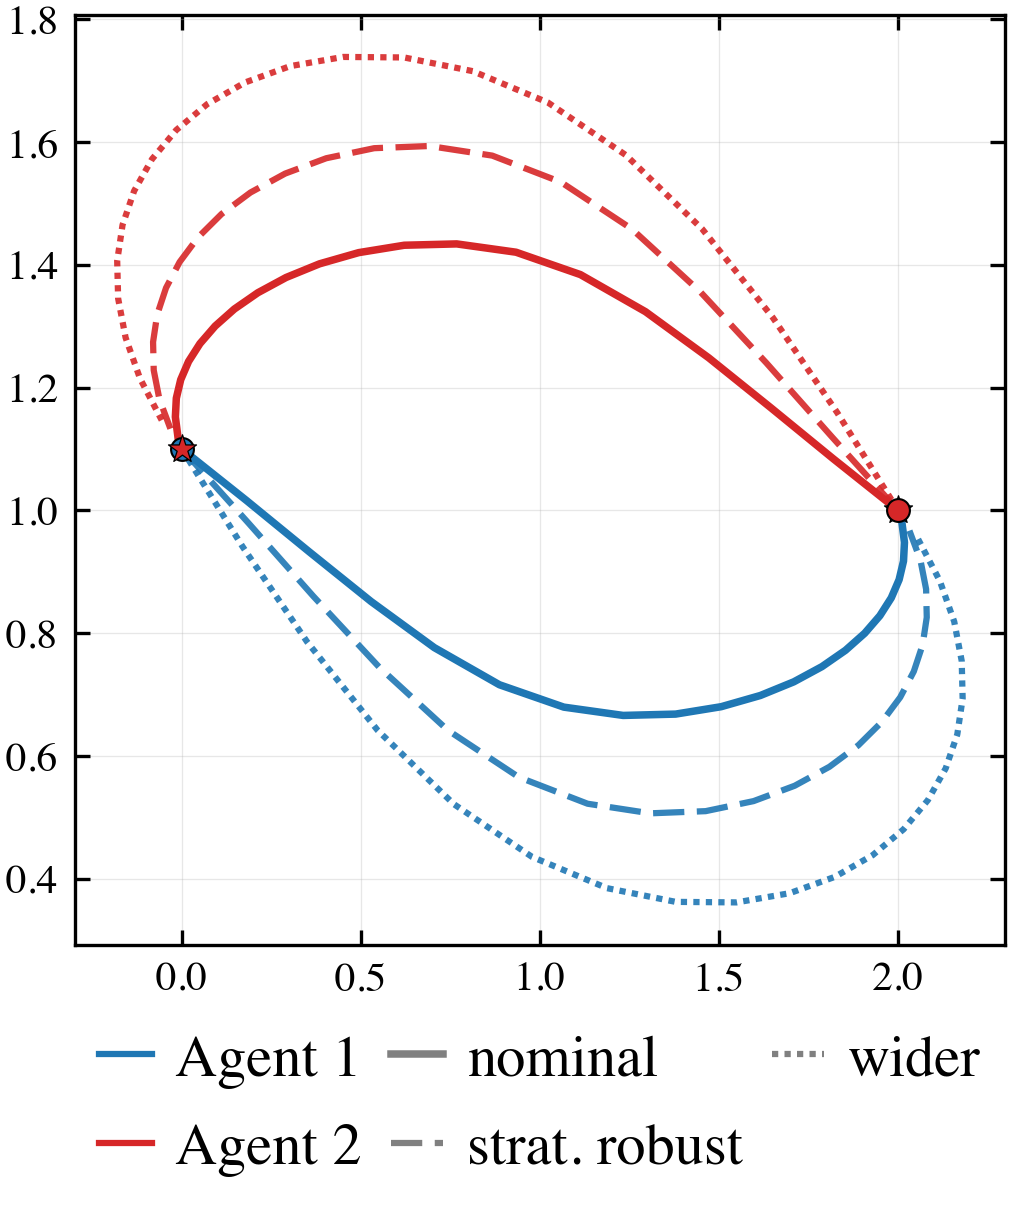

In [5]:
plotting.plot_trajectories(res_nominal, [res_robust, res_wider], n_a, H, sdim, cdim, xf,
                           method_labels=LABELS[:1] + ['strat. robust', 'wider'],
                           save_path=FIGDIR / 'headon_trajectories.png')
plt.show()

Both alternatives bow further out than the nominal plan, and wider bows
furthest. Distance from the nominal path is not the quantity of interest,
though — a plan can be far from nominal and still fragile. Section 4 measures
what each one is actually buying.

## 3. Relative coordinates

For a pair, only the relative state $z_t = x_{i,t} - x_{j,t}$ matters: the
origin *is* the collision. Solid curves are the plans as flown; dashed curves
are where an adversary with energy budget $\varepsilon = 2$ can drag them, one
point per horizon prefix.

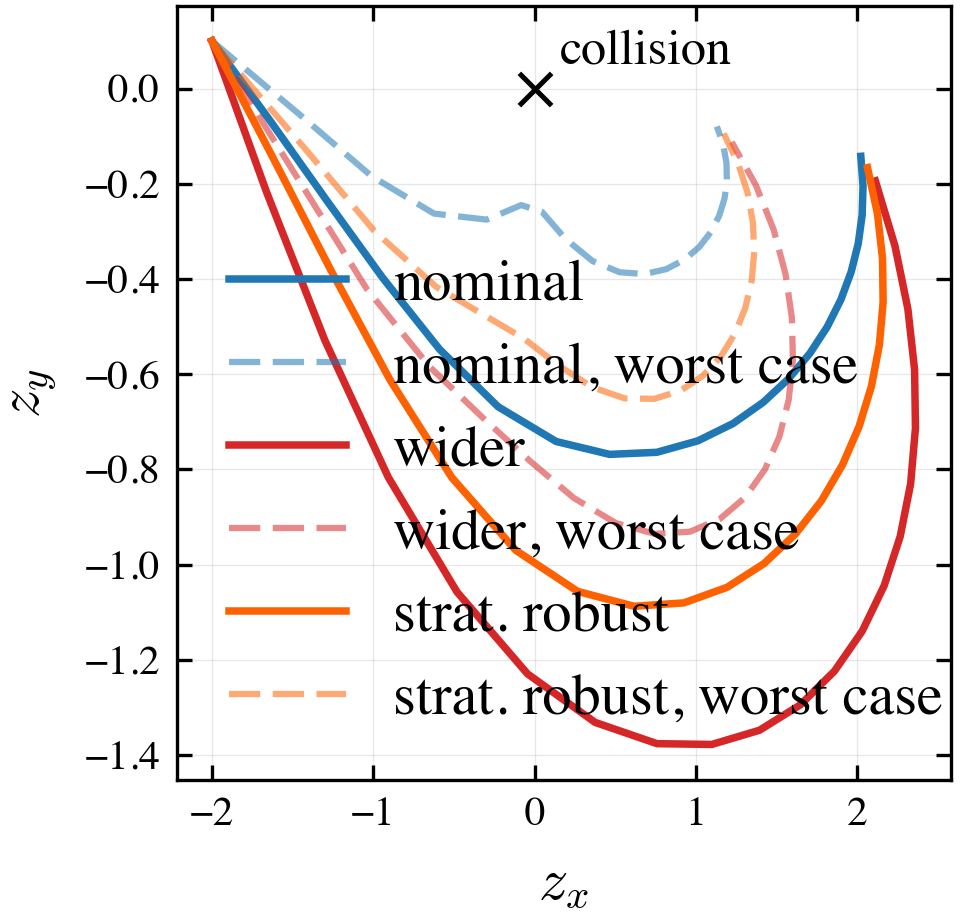

In [6]:
plotting.plot_relative_trajectory(RESULTS, LABELS, n_a, H, sdim, cdim, pdim, eps, A, B,
                                  save_path=FIGDIR / 'headon_relative.png')
plt.show()

## 4. What the adversary can take away

The gap between a method's solid and dashed curve above — and between its two
curves below — is the margin an adversary can erase. A robust plan is one whose
*dashed* curve stays up. Its solid curve need not be the highest.

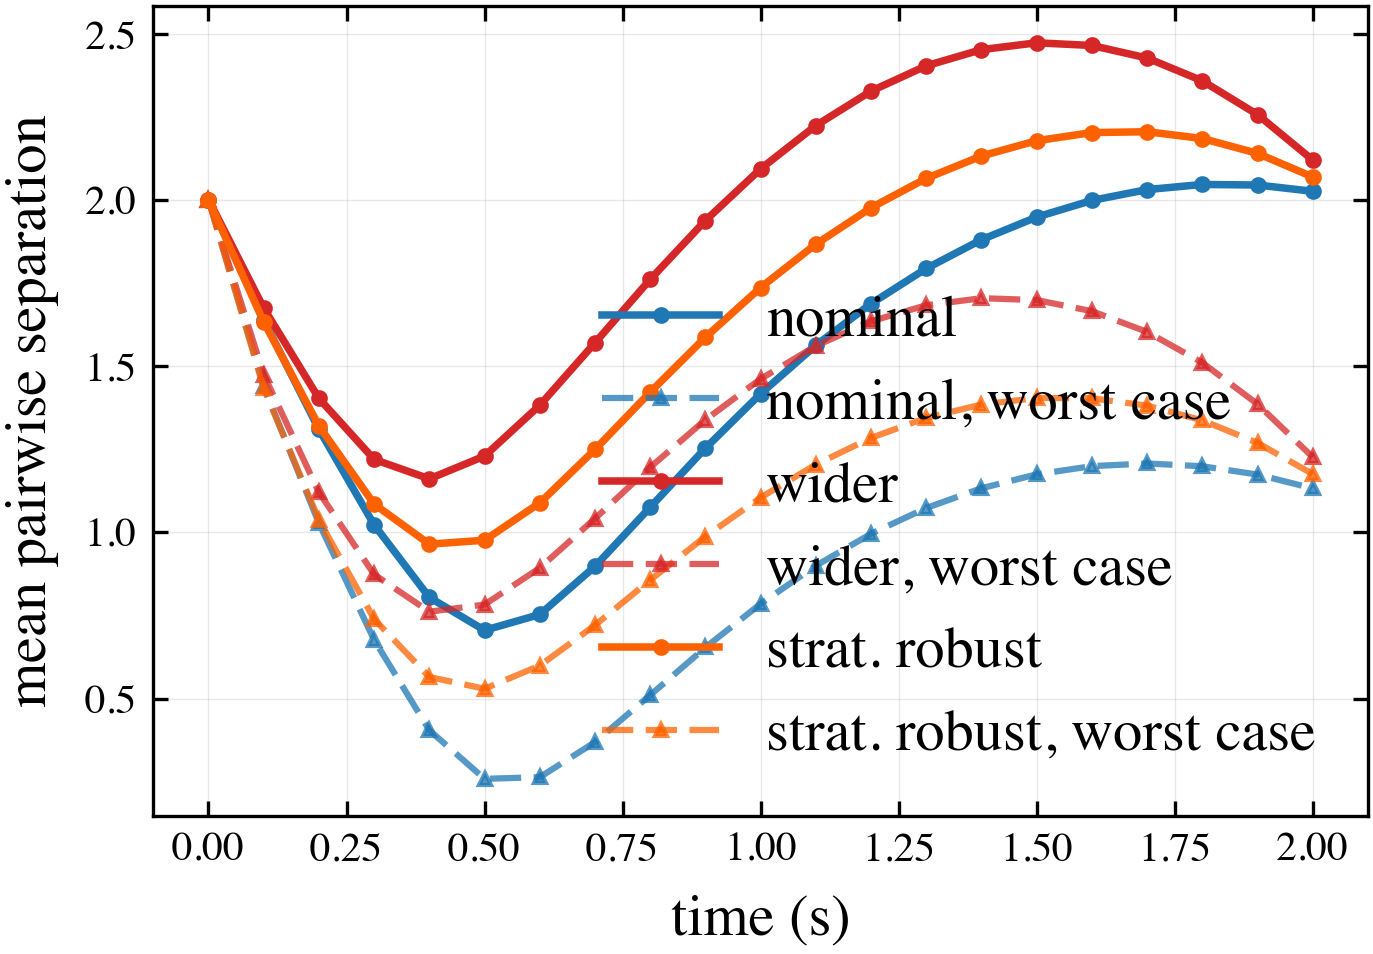

In [7]:
plotting.plot_avg_distances(RESULTS, LABELS, n_a, H, sdim, cdim, pdim, eps, A, B, dt,
                            save_path=FIGDIR / 'headon_separation.png')
plt.show()

In [8]:
sep = pd.DataFrame(plotting.min_separation_table(
    RESULTS, LABELS, n_a, H, sdim, cdim, pdim, eps, A, B)).set_index('method')
sep['worst-case margin vs nominal'] = (
    sep['min separation, worst case'] / sep.loc['nominal', 'min separation, worst case'])
sep

,min separation,"min separation, worst case",worst-case margin vs nominal
method,,,
nominal,0.7056,0.2583,1.0000
wider,1.1615,0.7615,2.9478
strat. robust,0.9649,0.5295,2.0496


## 5. Robustness is not a larger penalty

Both alternatives improve the worst case. The question is what each pays for it.
Integrated path deviation is the area between a method's trajectory and the
nominal one, averaged over agents — a direct measure of how much the plan had to
be distorted.

In [9]:
import benchmark_tables as bench

trade = []
for lab, res in zip(LABELS, RESULTS):
    x = split_solution(res, n_a, H, sdim, cdim)[0]
    trade.append({
        'method': lab,
        'path deviation': bench.integrated_path_deviation(x, x_nom, dt, pdim),
        'min separation, worst case': sep.loc[lab, 'min separation, worst case'],
    })
trade = pd.DataFrame(trade).set_index('method')
gain = trade['min separation, worst case'] - trade.loc['nominal', 'min separation, worst case']
trade['worst-case gain'] = gain
trade['gain per unit deviation'] = (gain / trade['path deviation']).replace([np.inf, -np.inf], np.nan)
trade

,path deviation,"min separation, worst case",worst-case gain,gain per unit deviation
method,,,,
nominal,0.0000,0.2583,0.0000,NaN
wider,0.5159,0.7615,0.5032,0.9754
strat. robust,0.2523,0.5295,0.2712,1.0748


The two are not interchangeable, but the difference is a trade rather than a
dominance. On this scenario the wider penalty buys *more* absolute worst-case
margin than robustness does — and pays more than twice the path deviation for
it. Per unit of distortion the two land within about 10% of each other, and
section 8 shows the ordering is not even stable across scenarios.

What does not trade away is where the number comes from. Wider's margin is set
by $c_1$, a tuning constant with no operational meaning: nothing tells you which
value corresponds to which level of protection, and the mapping moves with the
scenario. The robust margin is set by $\varepsilon$ — the disturbance energy the
plan is required to absorb, stated up front, in units. One is a knob you turn
until the picture looks safe; the other is an assumption you can defend.

## 6. Animation

Written to `figures/` and embedded as a GIF rather than as inline JavaScript;
the JavaScript form is what turns a notebook into a multi-megabyte file.

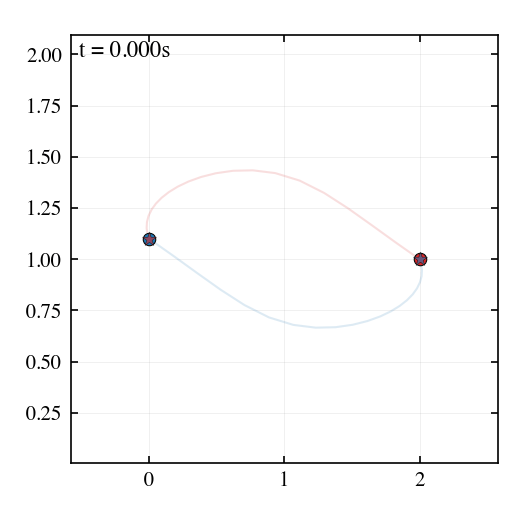

In [10]:
fig, anim = plotting.animate_trajectories(
    res_nominal, [res_robust], n_a, H, sdim, cdim, xf, dt,
    save_path=FIGDIR / 'headon_animation.gif')
plt.close(fig)
display(Image(filename=str(FIGDIR / 'headon_animation.gif')))

## 7. Parallel: a conflict the nominal plan never sees

The head-on case forces the issue — the two straight-line plans intersect, so
the nominal solver has to resolve a conflict whether or not anyone is robust.
The parallel case is the opposite, and it is the more revealing of the two.

Both agents travel the same direction, two apart, and never approach. The
nominal solve converges in a handful of iterations and the log barrier is
essentially inactive: there is nothing to avoid. Then give the adversary a
budget, and a conflict appears that the nominal planner had no reason to
anticipate.

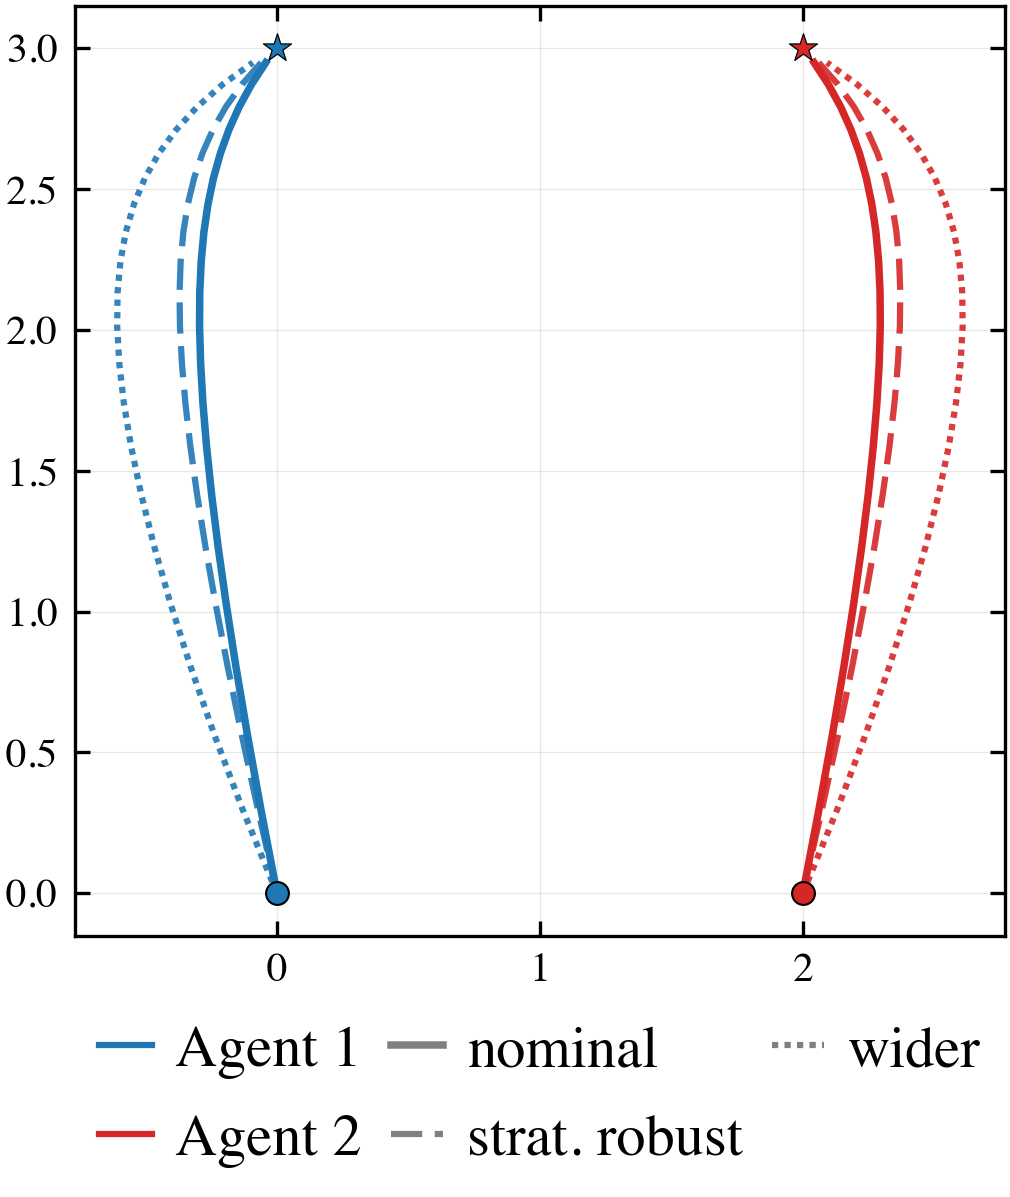

In [11]:
x0_par = np.array([[0.0, 0.0], [2.0, 0.0]])
xf_par = np.array([[0.0, 3.0], [2.0, 3.0]])
problem_par = (x0_par, xf_par, A, B, H, Q, R, Qf, n_a, sdim, cdim, pdim)

res_par_nominal = optimize_optimal_shooting(*problem_par, cost_nominal,
                                            distance_cost_grad_func=grad_nominal)
x_par_nom, u_par_nom = split_solution(res_par_nominal, n_a, H, sdim, cdim)
res_par_wider = optimize_optimal_shooting(*problem_par, cost_wider,
                                          distance_cost_grad_func=grad_wider,
                                          u_opt=u_par_nom)
res_par_robust = optimize_everystep_shooting(*problem_par, eps, cost_nominal,
                                             distance_cost_grad_func=grad_nominal,
                                             u_opt=u_par_nom)
RESULTS_PAR = [res_par_nominal, res_par_wider, res_par_robust]

plotting.plot_trajectories(res_par_nominal, [res_par_robust, res_par_wider],
                           n_a, H, sdim, cdim, xf_par,
                           method_labels=['nominal', 'strat. robust', 'wider'],
                           save_path=FIGDIR / 'parallel_trajectories.png')
plt.show()

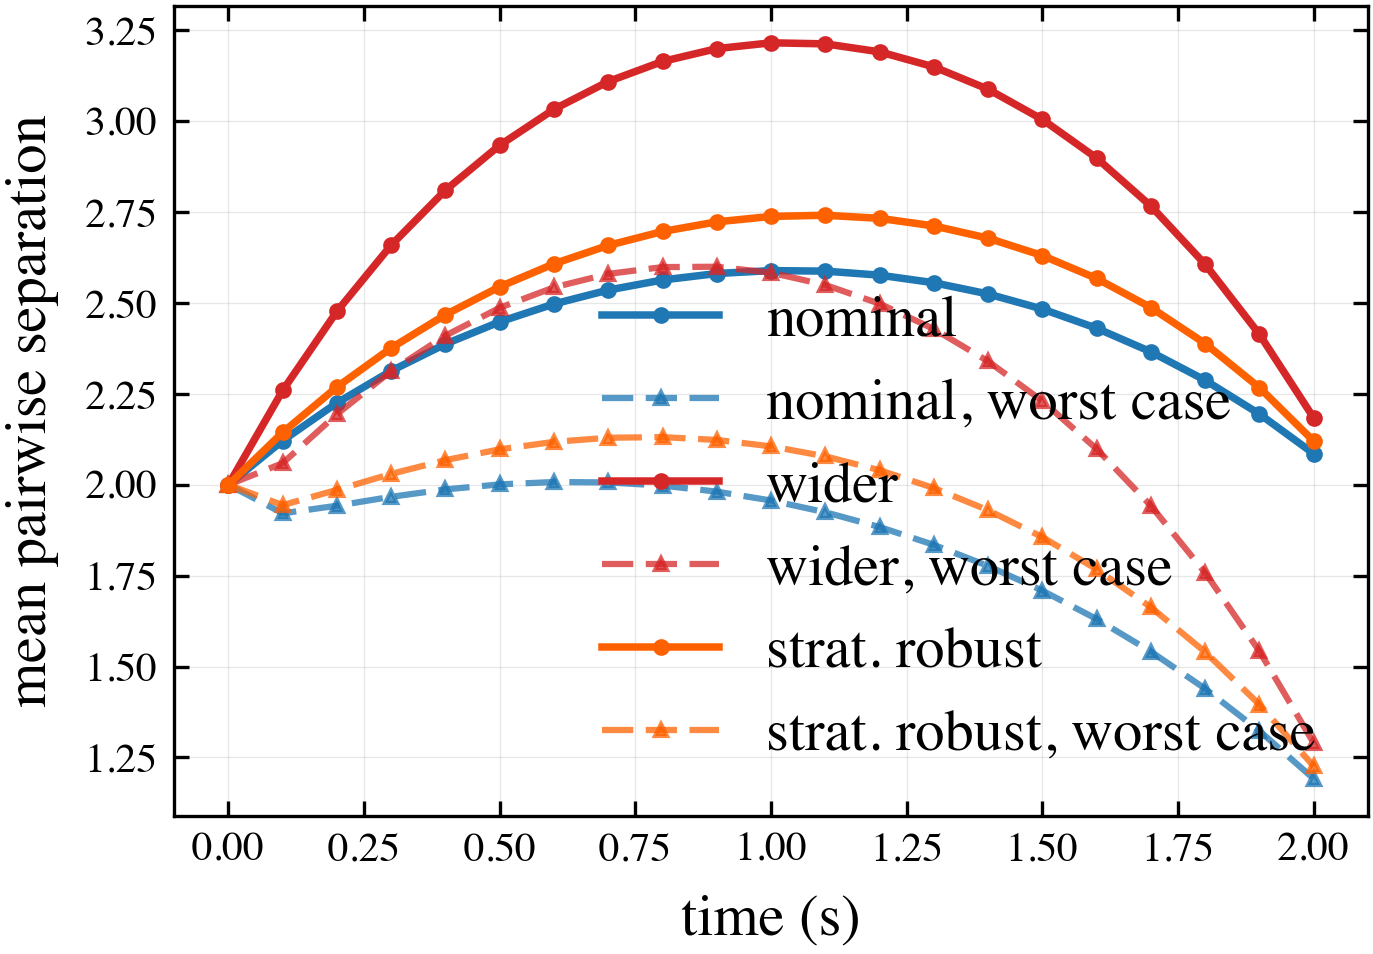

,min separation,"min separation, worst case",path deviation,worst-case gain,gain per unit deviation
method,,,,,
nominal,2.0,1.1911,0.0000,0.0000,NaN
wider,2.0,1.2894,0.4487,0.0983,0.2191
strat. robust,2.0,1.2255,0.1090,0.0345,0.3160


In [12]:
plotting.plot_avg_distances(RESULTS_PAR, LABELS, n_a, H, sdim, cdim, pdim, eps, A, B, dt,
                            save_path=FIGDIR / 'parallel_separation.png')
plt.show()

sep_par = pd.DataFrame(plotting.min_separation_table(
    RESULTS_PAR, LABELS, n_a, H, sdim, cdim, pdim, eps, A, B)).set_index('method')
sep_par['path deviation'] = [
    bench.integrated_path_deviation(split_solution(r, n_a, H, sdim, cdim)[0],
                                    x_par_nom, dt, pdim) for r in RESULTS_PAR]
gain_par = (sep_par['min separation, worst case']
            - sep_par.loc['nominal', 'min separation, worst case'])
sep_par['worst-case gain'] = gain_par
sep_par['gain per unit deviation'] = (
    gain_par / sep_par['path deviation']).replace([np.inf, -np.inf], np.nan)
sep_par

Read the nominal row against the head-on one in section 4. There the plans
crossed and the nominal solve was pushed down to a closest approach well under
one; here it stays at 2.0, the separation it started with, because the barrier
never engages. The nominal solve is *easy* — and the worst case still takes a
large bite out of that margin.

Note that the `min separation` column is identical for all three methods: the
agents travel in parallel and stay exactly their starting distance apart no
matter what. Every difference between the methods lives in the worst-case
column, which is the whole argument in one table.

The nominal planner is not being careless — by its own model there is no
conflict here at all. The margin only disappears once another agent is allowed
to deviate, which is exactly the uncertainty the nominal formulation has no way
to express.

This is also where the efficiency gap is widest. Compare the last column
against the same figure for the head-on case in section 5: the wider penalty
again buys more absolute margin, and again pays several times over for it, but
here the ratio between the two is far larger than the ~10% seen head-on.

It is also why the parallel row carries one of the highest runtime ratios in
section 10: the ratio is `1 + robust_iterations / nominal_iterations`, and the
denominator is small precisely because the nominal problem is so easy.

## 8. Four agents

Six pairs instead of one, and the interaction is no longer a single crossing:
agents must resolve conflicts with several neighbours at once. Everything below
is the same code with a different scenario.

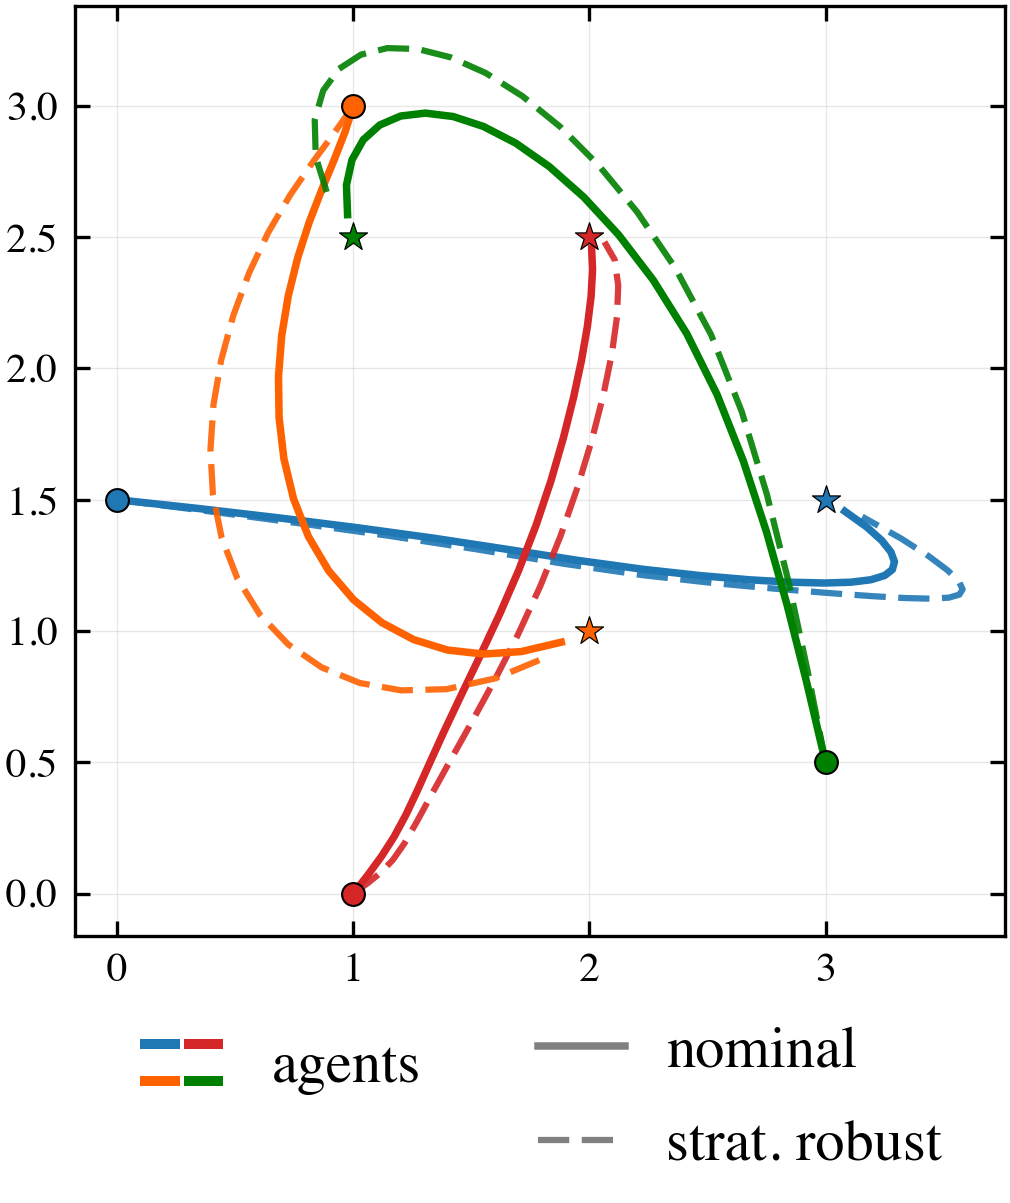

In [13]:
n_a4 = 4
x0_4 = np.array([[0.0, 1.5], [1.0, 0.0], [1.0, 3.0], [3.0, 0.5]])
xf_4 = np.array([[3.0, 1.5], [2.0, 2.5], [2.0, 1.0], [1.0, 2.5]])
problem4 = (x0_4, xf_4, A, B, H, Q, R, Qf, n_a4, sdim, cdim, pdim)

res4_nominal = optimize_optimal_shooting(*problem4, cost_nominal,
                                         distance_cost_grad_func=grad_nominal)
x4_nom, u4_nom = split_solution(res4_nominal, n_a4, H, sdim, cdim)
res4_wider = optimize_optimal_shooting(*problem4, cost_wider,
                                       distance_cost_grad_func=grad_wider, u_opt=u4_nom)
res4_robust = optimize_everystep_shooting(*problem4, eps, cost_nominal,
                                          distance_cost_grad_func=grad_nominal,
                                          u_opt=u4_nom)
RESULTS4 = [res4_nominal, res4_wider, res4_robust]

# Only nominal and robust are drawn: at four agents the wider curves add twelve
# more lines without adding to the comparison, which the tables below carry.
plotting.plot_trajectories(res4_nominal, [res4_robust], n_a4, H, sdim, cdim, xf_4,
                           method_labels=['nominal', 'strat. robust'],
                           save_path=FIGDIR / '4agent_trajectories.png')
plt.show()

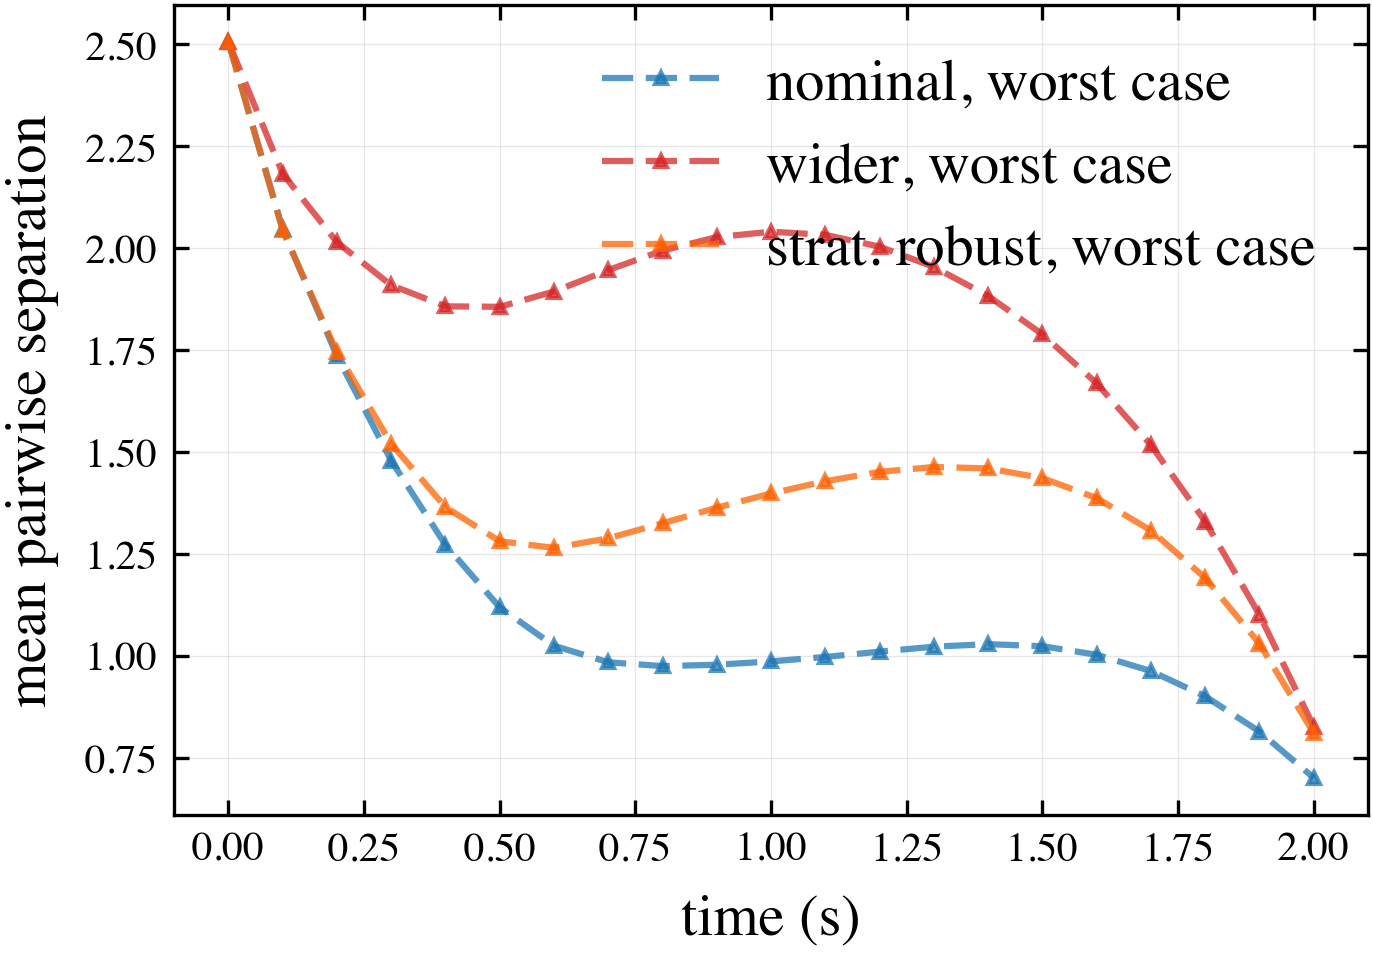

,min separation,"min separation, worst case"
method,,
nominal,0.9652,0.1470
wider,1.1153,0.2209
strat. robust,1.0753,0.2790


In [14]:
plotting.plot_avg_distances(RESULTS4, LABELS, n_a4, H, sdim, cdim, pdim, eps, A, B, dt,
                            show_nominal=False,
                            save_path=FIGDIR / '4agent_separation.png')
plt.show()

pd.DataFrame(plotting.min_separation_table(
    RESULTS4, LABELS, n_a4, H, sdim, cdim, pdim, eps, A, B)).set_index('method')

Read those two outputs against each other, because they disagree.

On the **mean** worst-case separation the wider penalty sits well above the
robust solve. On the **minimum** over all six pairs and every step — the
quantity a safety claim actually rests on — the ordering reverses, and
robustness wins on both axes at once: a larger worst-case margin for less than
half the path deviation.

The mean is what hides it. Averaging over six pairs lets slack in five of them
cover a tight sixth, and a wider penalty buys exactly that kind of slack — it
pushes every pair apart uniformly, including the ones that were never in
danger. The robust solve spends its distortion where the adversary would
actually attack.

## 9. Eight agents on a circle

The stress case: eight agents evenly spaced on a circle of radius 2, each
heading to the diametrically opposite point. Every straight-line plan passes
through the centre, so all 28 pairs conflict at once and the nominal solve has
to find a rotation for the whole formation.

Note how the cost distributes: the robust solve, warm-started, is *faster* than
the nominal one it starts from. Under the full-space solver this cell took ~55 s;
by shooting it takes about three.

In [15]:
n_a8 = 8
angles = np.linspace(0, 2 * np.pi, n_a8, endpoint=False)
centre, radius = np.array([2.0, 2.0]), 2.0
x0_8 = np.array([centre + radius * np.array([np.cos(a), np.sin(a)]) for a in angles])
xf_8 = np.array([centre - radius * np.array([np.cos(a), np.sin(a)]) for a in angles])
problem8 = (x0_8, xf_8, A, B, H, Q, R, Qf, n_a8, sdim, cdim, pdim)

t0 = time.perf_counter()
res8_nominal = optimize_optimal_shooting(*problem8, cost_nominal,
                                         distance_cost_grad_func=grad_nominal)
t8_nominal = time.perf_counter() - t0
x8_nom, u8_nom = split_solution(res8_nominal, n_a8, H, sdim, cdim)

t0 = time.perf_counter()
res8_robust = optimize_everystep_shooting(*problem8, eps, cost_nominal,
                                          distance_cost_grad_func=grad_nominal,
                                          u_opt=u8_nom)
t8_robust = time.perf_counter() - t0

print(f'nominal: {t8_nominal:6.2f}s   robust (warm-started): {t8_robust:6.2f}s')

nominal:   2.12s   robust (warm-started):   0.96s


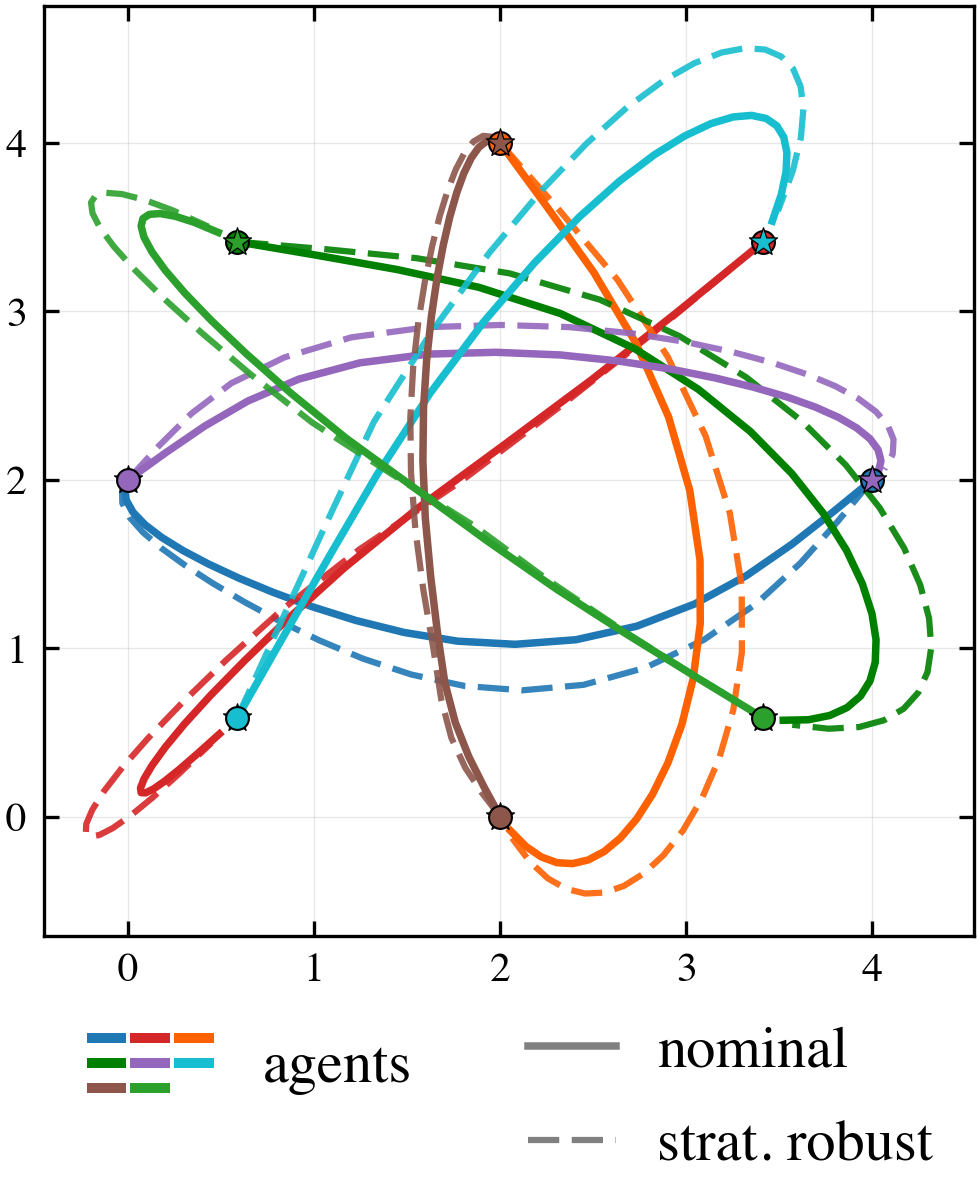

In [16]:
plotting.plot_trajectories(res8_nominal, [res8_robust], n_a8, H, sdim, cdim, xf_8,
                           method_labels=['nominal', 'strat. robust'],
                           save_path=FIGDIR / '8agent_trajectories.png')
plt.show()

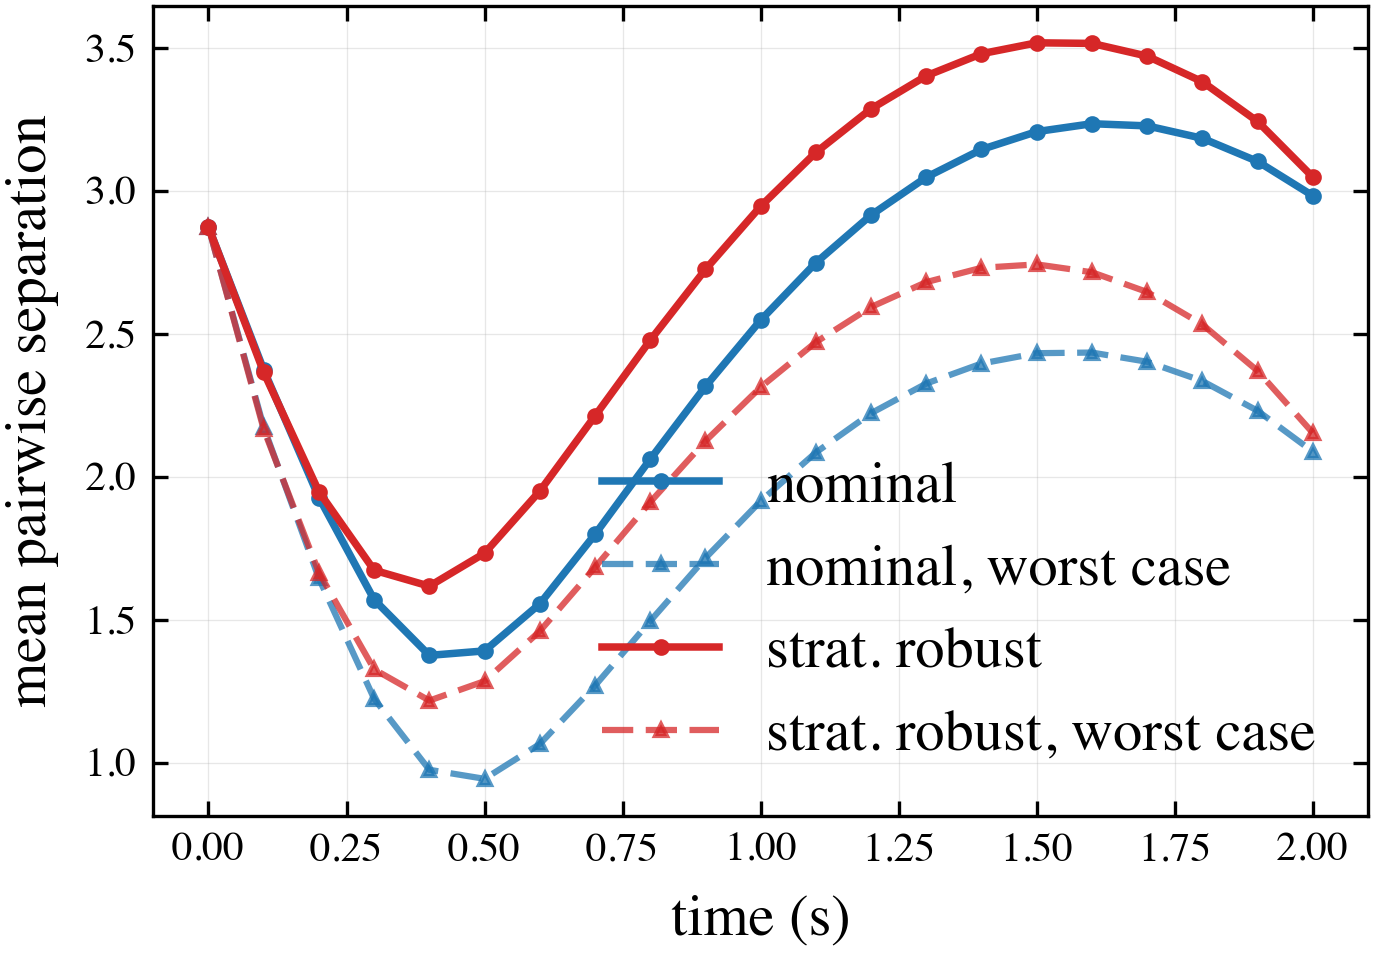

,min separation,"min separation, worst case"
method,,
nominal,0.4214,0.0214
strat. robust,0.5879,0.2347


In [17]:
plotting.plot_avg_distances([res8_nominal, res8_robust], ['nominal', 'strat. robust'],
                            n_a8, H, sdim, cdim, pdim, eps, A, B, dt,
                            save_path=FIGDIR / '8agent_separation.png')
plt.show()

pd.DataFrame(plotting.min_separation_table(
    [res8_nominal, res8_robust], ['nominal', 'strat. robust'],
    n_a8, H, sdim, cdim, pdim, eps, A, B)).set_index('method')

## 10. Runtime

`benchmark_tables.py` produces the paper's timing tables and is importable, so
the same code runs here and on a headless box. Three conventions in it are
worth knowing, each the result of a measurement that turned out to be wrong:

1. **Analytic gradients on every method**, including the nominal baseline and
   the nominal initialization inside the robust solve. Mixing modes made the
   8-agent robust overhead read 3.72x instead of 1.29x, because the
   finite-difference baseline stopped early on a worse optimum.
2. **Median reported next to mean.** One outlying run moved the 4-agent ratio
   from 1.89x to 1.72x under the mean. CV is printed so a noisy row is visible.
3. **Objectives recorded and checked for uniqueness.** If the runs in a cell
   did not all land on the same optimum, the spread is a mix of local minima
   rather than machine noise, and the row must not be averaged. The `uniq`
   column flags it.

The robust timing includes its own nominal initialization, so the ratio is the
honest end-to-end cost of switching methods, not the marginal cost of the
robust solve alone.

`USE_SHOOTING` switches every row to the same parameterization the rest of this
notebook uses. Expect *higher* ratios than the full-space table in the README,
and that is the more honest measurement: in the full space 96-100% of every
SLSQP iteration is the constrained QP, a cost both methods pay identically,
which hides the robust objective and gradient evaluation almost entirely.
Shooting removes the QP and the difference becomes visible.

In [18]:
bench.USE_SHOOTING = True

results_bench = [bench.run_scenario(name, BENCH_RUNS, verbose=False)
                 for name in ('Head-on', 'Parallel', '4 agents')]
results_bench.append(bench.run_scenario('8 agents', BENCH_RUNS_8, verbose=False))

rows = []
for r in results_bench:
    s = bench.summarize(r)
    for method in ('nominal', 'wider', 'robust'):
        rows.append({
            'scenario': r['scenario'], 'n_a': r['n_a'],
            'method': bench.LABEL[method],
            'median (s)': s[method]['median'],
            'ratio': s[method]['ratio_median'],
            'CV': s[method]['cv'],
            'iterations': s[method]['nit'],
            'path deviation': r['deviation'][method],
            'objective': s[method]['objective'],
            'uniq': s[method]['objective_unique'],
        })
runtime = pd.DataFrame(rows).set_index(['scenario', 'method'])
runtime

n_a  median (s)   ratio      CV  iterations  \
scenario method                                                       
Head-on  Nominal          2      0.0229  1.0000  0.0193        32.0   
         Wider            2      0.0234  1.0209  0.0064        33.0   
         Strat. Robust    2      0.0334  1.4549  0.0089        12.0   
Parallel Nominal          2      0.0064  1.0000  0.0216         8.0   
         Wider            2      0.0076  1.1828  0.0170        10.0   
         Strat. Robust    2      0.0127  1.9851  0.0163         7.0   
4 agents Nominal          4      0.0816  1.0000  0.0047        25.0   
         Wider            4      0.0852  1.0440  0.0104        26.0   
         Strat. Robust    4      0.1574  1.9294  0.0053        20.0   
8 agents Nominal          8      2.1281  1.0000  0.0015        92.0   
         Wider            8      2.3510  1.1047  0.0147       101.0   
         Strat. Robust    8      3.1151  1.4638  0.0591        37.0   

                        path deviation  objective  uniq  
scenario method                                          
Head-on  Nominal                0.0000    73.3080     1  
         Wider                  0.5159     8.3905     1  
         Strat. Robust          0.2523   116.4260     1  
Parallel Nominal                0.0000   128.6423     1  
         Wider                  0.4487     8.0438     1  
         Strat. Robust          0.1090   154.9635     1  
4 agents Nominal                0.0000   181.0621     1  
         Wider                  0.9532  -348.5486     1  
         Strat. Robust          0.4048   428.1921     1  
8 agents Nominal                0.0000    36.6866     1  
         Wider                  1.3681 -3389.7336     1  
         Strat. Robust          0.4109   884.7809     1

Every `uniq` above must be 1. Anything else means that cell mixed local minima
and its timings are not a like-for-like average.

The headline number is the `ratio` column on the **Strat. Robust** rows: the
multiple of nominal runtime that strategic robustness costs, end to end.

In [19]:
print(bench.format_tables(results_bench, stat='median'))


### Head-on  (n=5, ratios by median, single shooting)
method              mean   median     std     CV   nit   ratio  deviation           obj  uniq
---------------------------------------------------------------------------------------------
Nominal           0.0231   0.0229  0.0004  1.9%    32   1.00x     0.0000       73.3080     1
Wider             0.0234   0.0234  0.0002  0.6%    33   1.02x     0.5159        8.3905     1
Strat. Robust     0.0333   0.0334  0.0003  0.9%    12   1.45x     0.2523      116.4260     1

wall breakdown  measured overhead   total  share  per run
Nominal             0.12     0.05    0.16 33.3%    0.023
Wider               0.12     0.02    0.14 28.1%    0.023
Strat. Robust       0.17     0.02    0.19 38.6%    0.033
scenario total      0.40     0.09    0.48                  (unattributed +0.00s)

### Parallel  (n=5, ratios by median, single shooting)
method              mean   median     std     CV   nit   ratio  deviation           obj  uniq
-----------------

## 11. What the full space would have given

Everything above used single shooting. The alternative keeps $x$ and $u$ as
decision variables and enforces the dynamics as equality constraints — 336 of
them at eight agents, on top of twice the variables.

The two do not start from the same point: the full-space default guess
interpolates $x$ linearly with $u = 0$, a pair its own dynamics do not produce,
and shooting cannot represent an inconsistent start. On the smaller scenarios
they converge to the same optimum anyway. At eight agents they do not, and it
is shooting that finds the better one — so compare objectives alongside times.

In [20]:
t0 = time.perf_counter()
res8_nominal_f = optimize_optimal(*problem8, cost_nominal,
                                  distance_cost_grad_func=grad_nominal)
t8_nominal_f = time.perf_counter() - t0
x8_nom_f, u8_nom_f = split_solution(res8_nominal_f, n_a8, H, sdim, cdim)

t0 = time.perf_counter()
res8_robust_f = optimize_everystep(*problem8, eps, cost_nominal,
                                   distance_cost_grad_func=grad_nominal,
                                   x_opt=x8_nom_f, u_opt=u8_nom_f)
t8_robust_f = time.perf_counter() - t0

pd.DataFrame([
    {'method': 'nominal', 'parameterization': 'single shooting',
     'seconds': t8_nominal, 'objective': res8_nominal.fun, 'iterations': res8_nominal.nit},
    {'method': 'nominal', 'parameterization': 'full space',
     'seconds': t8_nominal_f, 'objective': res8_nominal_f.fun, 'iterations': res8_nominal_f.nit},
    {'method': 'strat. robust', 'parameterization': 'single shooting',
     'seconds': t8_robust, 'objective': res8_robust.fun, 'iterations': res8_robust.nit},
    {'method': 'strat. robust', 'parameterization': 'full space',
     'seconds': t8_robust_f, 'objective': res8_robust_f.fun, 'iterations': res8_robust_f.nit},
]).set_index(['method', 'parameterization'])

seconds  objective  iterations
method        parameterization                                
nominal       single shooting    2.1201    36.6866          92
              full space        42.6511    48.3576         131
strat. robust single shooting    0.9570   884.7809          37
              full space        10.3670   902.5395          32

The full-space nominal solve stops at a worse optimum (higher objective) and
takes an order of magnitude longer to get there. Its robust solve inherits that
start, which is why the worst-case margin in section 9 is better than the
full-space figures quoted in the README.

## 12. An alternative encoding

Every figure above uses color for the agent and dash pattern for the method,
with the eight agent colors collapsed into one "agents" swatch so the legend
stays at three entries. That keeps individual trajectories followable while
spending almost no legend on them.

The alternative gives up agent identity entirely: one color per **method**,
all agents pooled into it. Nothing here argues about a particular agent, so
little is lost, and the two bundles land in direct contrast rather than asking
the reader to separate dash patterns inside eight hues. Which one is better
depends on whether a reader ever needs to trace a single agent's path.

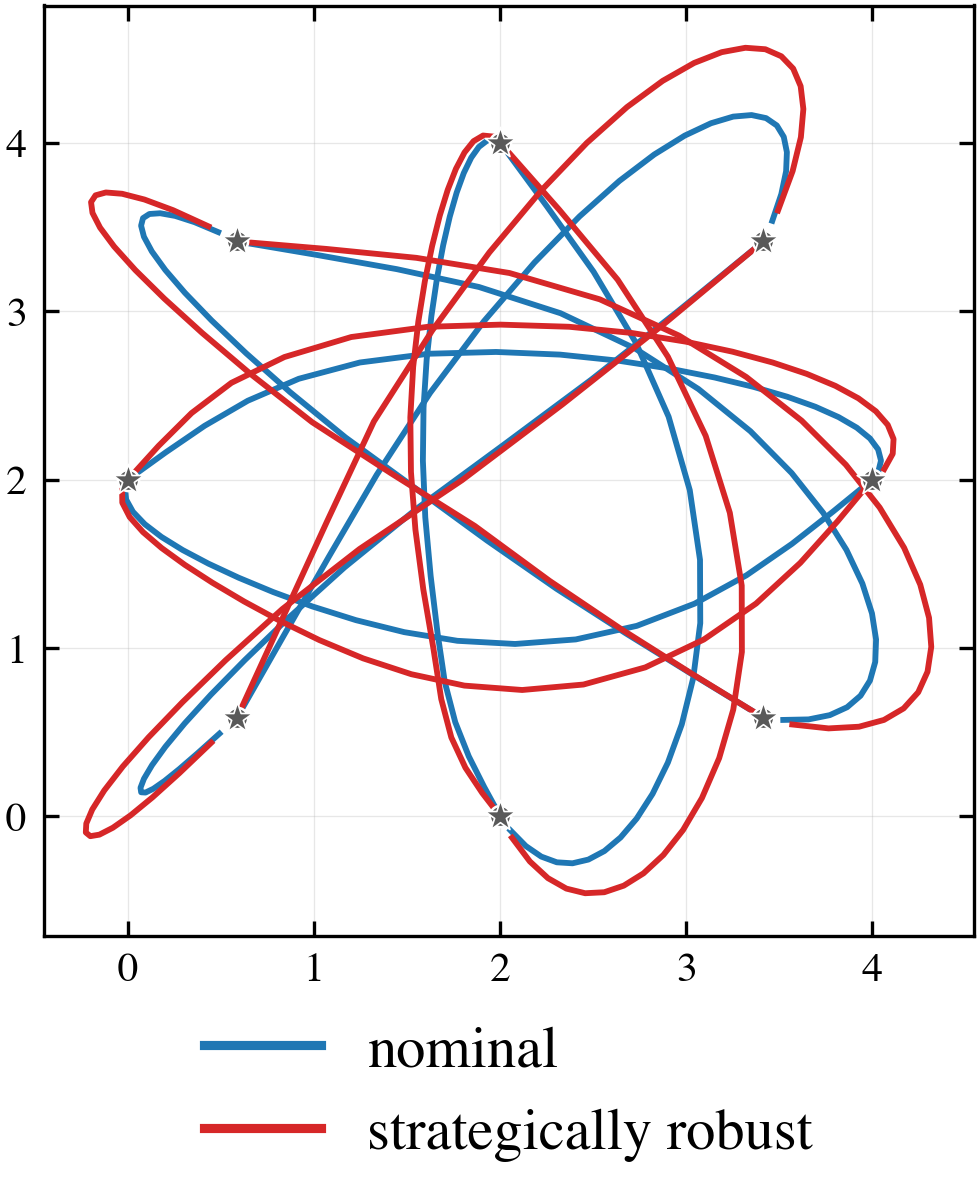

In [21]:
plotting.plot_trajectories_by_method(
    [res8_nominal, res8_robust], ['nominal', 'strategically robust'],
    n_a8, H, sdim, cdim, xf_8,
    save_path=FIGDIR / '8agent_bundle.png')
plt.show()

Either encoding shows the robust bundle sitting outside the nominal one. The
numbers below say how far, and how evenly — computed rather than quoted, since
they move whenever the solver or its parameterization does.

In [22]:
centre = np.array([2.0, 2.0])
x8_rob = split_solution(res8_robust, n_a8, H, sdim, cdim)[0]
res8_wider = optimize_optimal_shooting(*problem8, cost_wider,
                                       distance_cost_grad_func=grad_wider, u_opt=u8_nom)
x8_wide = split_solution(res8_wider, n_a8, H, sdim, cdim)[0]

def per_agent_deviation(x):
    return np.array([bench.integrated_path_deviation(x[i:i + 1], x8_nom[i:i + 1], dt, pdim)
                     for i in range(n_a8)])

closest = lambda x: np.linalg.norm(x[:, :, :pdim] - centre, axis=2).min(axis=1)
dev_rob, dev_wide = per_agent_deviation(x8_rob), per_agent_deviation(x8_wide)
near_nom, near_rob = closest(x8_nom), closest(x8_rob)

print(f'agents ending further from the centre : {(near_rob > near_nom).sum()} of {n_a8}')
print(f'mean closest approach to the centre   : {near_nom.mean():.2f} -> {near_rob.mean():.2f}')
print(f'robust per-agent deviation            : {dev_rob.min():.2f} to {dev_rob.max():.2f}'
      f'  ({dev_rob.max() / dev_rob.min():.1f}x spread)')
print(f'mean deviation, robust vs wider       : {dev_rob.mean():.2f} vs {dev_wide.mean():.2f}')

agents ending further from the centre : 6 of 8
mean closest approach to the centre   : 0.68 -> 0.78
robust per-agent deviation            : 0.13 to 0.65  (4.9x spread)
mean deviation, robust vs wider       : 0.41 vs 1.37


Two things to read off that. The robust solve pushes most of the formation
away from the centre, but *not uniformly* — the per-agent spread is several
fold, so it redistributes the formation rather than simply inflating it. And it
is cheap in distortion: its mean per-agent deviation is a fraction of what the
wider penalty spends to buy a smaller worst-case margin.

---

**Where to go next.** `adversary.py` documents the closed form for the worst
case. The appendix of `README.md` derives the other half — why the adversary's
response never appears in the gradient, since the envelope theorem removes it,
and how an earlier derivation that differentiated through the Riccati recursion
came out wrong by order 10. The paper gives the first half (Appendix B) but not
the second.